<Figure size 640x480 with 0 Axes>

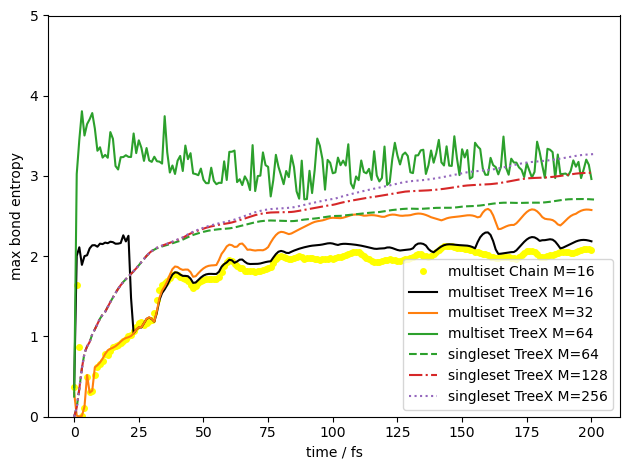

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

AU_TO_FS = 0.02418884326505
base = Path("..")
if not (base / "multiset_treeX").exists():
    base = Path("multiset_ttn/P3HT:PCBM")

multiset_chain_paths = {
    16: base / "multiset_chain/p3ht_ms_ttn_chain_16.npz",
}

multiset_treex_paths = {
    16: base / "multiset_treeX/p3ht_ms_ttn_treeX_16.npz",
    32: base / "multiset_treeX/p3ht_ms_ttn_treeX_32.npz",
    64: base / "multiset_treeX/p3ht_ms_ttn_treeX_64.npz",
}
singleset_treex_path = base / "2026Further_plot/figures/Tree4.npz"
singleset_treex_m_list = [64, 128, 256]

def load_max_bond_entropy(path):
    with np.load(path, allow_pickle=True) as data:
        time = data["time_fs"] if "time_fs" in data else data["time series"] * AU_TO_FS
        for key in ("S_maxbond", "max_bond_entropy", "maxbond_entropy"):
            if key in data:
                return time, np.real_if_close(data[key])
        for key in ("bond_entropy", "bond_vn_entropy", "entropy"):
            if key in data:
                entropy = np.real_if_close(data[key])
                return time, entropy if entropy.ndim == 1 else np.max(entropy, axis=1)
        raise KeyError(f"{path} has no saved bond entropy key; keys={list(data.files)}")

def load_draw_entropy(path, max_bd):
    with np.load(path) as data:
        m_idx = data["M"].astype(str).tolist().index(str(max_bd))
        entropy = np.max(data["entropy"][m_idx], axis=1)
    return np.arange(entropy.shape[0]), entropy

colors = {16: "black", 32: "C1", 64: "C2", 128: "C3", 256: "C4", 512: "C5"}
linestyles = {64: "--", 128: "-.", 256: ":", 512: (0, (3, 1, 1, 1))}
plt.figure()

plt.figure()

for max_bd, path in multiset_chain_paths.items():
    time, entropy = load_max_bond_entropy(path)
    plt.plot(
        time,
        entropy,
        "o",
        color="yellow",
        label=f"multiset Chain M={max_bd}",
        markersize=4,
    )

for max_bd, path in multiset_treex_paths.items():
    time, entropy = load_max_bond_entropy(path)
    plt.plot(
        time,
        entropy,
        "-",
        color=colors[max_bd],
        label=f"multiset TreeX M={max_bd}",
    )

for max_bd in singleset_treex_m_list:
    time, entropy = load_draw_entropy(singleset_treex_path, max_bd)
    plt.plot(
        time,
        entropy,
        ls=linestyles[max_bd],
        color=colors[max_bd],
        label=f"singleset TreeX M={max_bd}",
    )

plt.xlabel("time / fs")
plt.ylabel("max bond entropy")
plt.ylim(0, 5)
plt.legend()
plt.tight_layout()


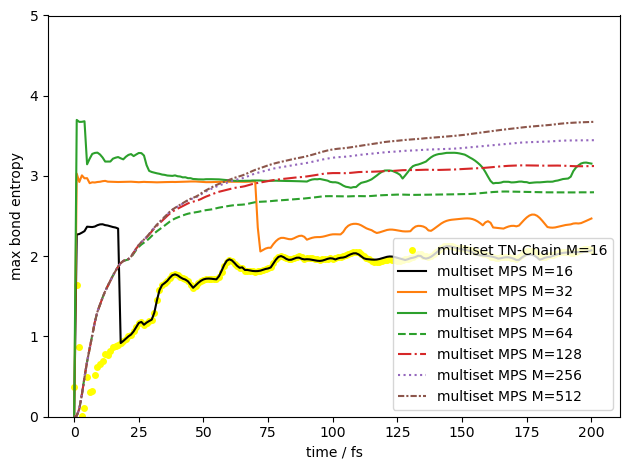

In [2]:
repo = Path("../../..")
if not (repo / "multiset_202605").exists():
    repo = Path(".")

multiset_mps_paths = {
    16: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_16.npz",
    32: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_32.npz",
    64: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_64.npz",
}

chain_path = base / "2026Further_plot/figures/MPS.npz"
chain_m_list = [64, 128, 256, 512]

plt.figure()

# Add the yellow-o multiset Chain result from the first plot
for max_bd, path in multiset_chain_paths.items():
    time, entropy = load_max_bond_entropy(path)
    plt.plot(
        time,
        entropy,
        "o",
        color="yellow",
        label=f"multiset TN-Chain M={max_bd}",
        markersize=4,
    )

# Multiset MPS results
for max_bd, path in multiset_mps_paths.items():
    time, entropy = load_max_bond_entropy(path)
    plt.plot(
        time,
        entropy,
        "-",
        color=colors[max_bd],
        label=f"multiset MPS M={max_bd}",
    )

# Singleset chain results
for max_bd in chain_m_list:
    time, entropy = load_draw_entropy(chain_path, max_bd)
    plt.plot(
        time,
        entropy,
        ls=linestyles[max_bd],
        color=colors[max_bd],
        label=f"multiset MPS M={max_bd}",
    )

plt.xlabel("time / fs")
plt.ylim(0, 5)
plt.ylabel("max bond entropy")
plt.legend()
plt.tight_layout()

Skipped files without usable S_maxbond_unnormed:
  'p3ht_multiset_128.npz has no S_maxbond_unnormed; rerun this job with the updated entropy code'
saved ../../../multiset_ttn/P3HT:PCBM/plot/p3ht_S_maxbond_unnormed_mps_vs_treex.png


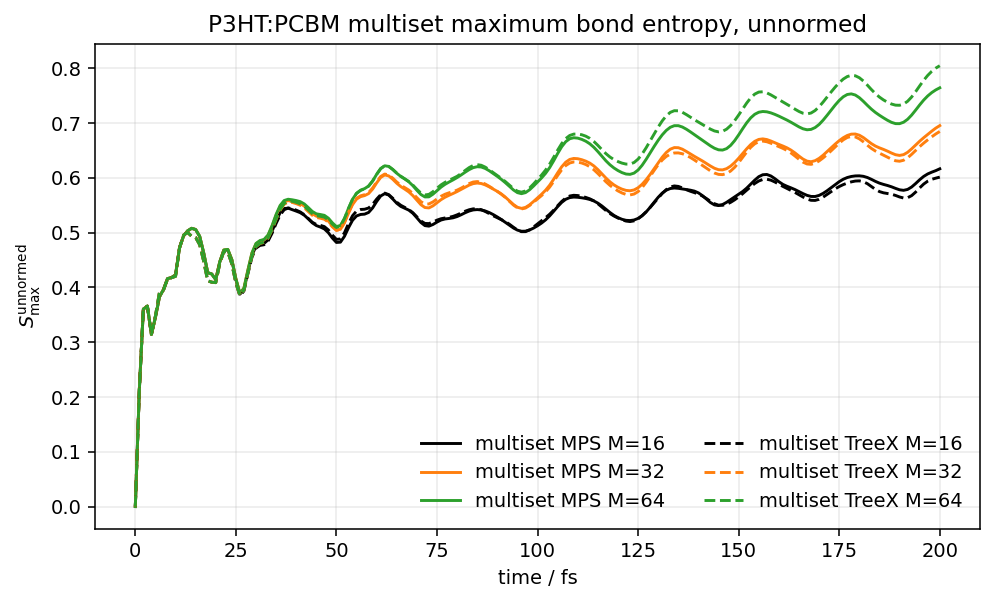

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

AU_TO_FS = globals().get("AU_TO_FS", 0.02418884326505)


def find_repo_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "renormalizer").exists() and (path / "multiset_ttn").exists():
            return path
    return Path.cwd()


repo = globals().get("repo", find_repo_root())
plot_dir = repo / "multiset_ttn/P3HT:PCBM/plot"

mps_paths = {
    16: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_16.npz",
    32: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_32.npz",
    64: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_64.npz",
    128: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_128.npz",
}

treex_paths = {
    16: repo / "multiset_ttn/P3HT:PCBM/multiset_treeX/p3ht_ms_ttn_treeX_16.npz",
    32: repo / "multiset_ttn/P3HT:PCBM/multiset_treeX/p3ht_ms_ttn_treeX_32.npz",
    64: repo / "multiset_ttn/P3HT:PCBM/multiset_treeX/p3ht_ms_ttn_treeX_64.npz",
}


def load_smaxbond_unnormed(path):
    with np.load(path, allow_pickle=True) as data:
        if "S_maxbond_unnormed" not in data:
            raise KeyError(f"{path.name} has no S_maxbond_unnormed; rerun this job with the updated entropy code")
        entropy = np.real_if_close(data["S_maxbond_unnormed"]).squeeze()
        if entropy.ndim != 1:
            raise ValueError(f"{path.name} S_maxbond_unnormed must be 1D, got {entropy.shape}")
        if "time_fs" in data:
            time = np.real_if_close(data["time_fs"]).squeeze()
        elif "time series" in data:
            time = np.real_if_close(data["time series"]).squeeze() * AU_TO_FS
        else:
            time = np.arange(len(entropy))
        if len(time) != len(entropy):
            raise ValueError(f"{path.name} time length {len(time)} != entropy length {len(entropy)}")
        return time, entropy


fig, ax = plt.subplots(figsize=(7.2, 4.4), dpi=140)
colors = globals().get("colors", {16: "black", 32: "C1", 64: "C2", 128: "C3"})
skipped = []
plotted = 0

for max_bd, path in mps_paths.items():
    try:
        time, entropy = load_smaxbond_unnormed(path)
    except (FileNotFoundError, KeyError, ValueError) as exc:
        skipped.append(str(exc))
        continue
    ax.plot(time, entropy, "-", color=colors.get(max_bd), label=f"multiset MPS M={max_bd}")
    plotted += 1

for max_bd, path in treex_paths.items():
    try:
        time, entropy = load_smaxbond_unnormed(path)
    except (FileNotFoundError, KeyError, ValueError) as exc:
        skipped.append(str(exc))
        continue
    ax.plot(time, entropy, "--", color=colors.get(max_bd), label=f"multiset TreeX M={max_bd}")
    plotted += 1

if plotted == 0:
    raise RuntimeError("No S_maxbond_unnormed data were loaded.")

if skipped:
    print("Skipped files without usable S_maxbond_unnormed:")
    for message in skipped:
        print("  " + message)

ax.set_xlabel("time / fs")
ax.set_ylabel(r"$S_{\max}^{\mathrm{unnormed}}$")
ax.set_title("P3HT:PCBM multiset maximum bond entropy, unnormed")
ax.grid(alpha=0.25)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()

out = plot_dir / "p3ht_S_maxbond_unnormed_mps_vs_treex.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")


Skipped files without usable maximum bond entropy:
  multiset MPS M=128: "p3ht_multiset_128.npz has none of ('S_maxbond_unnormed',); keys=['mol list', 'temperature', 'time series', 'electron occupations array']"
  singleset TreeX M=16: "p3ht_ttns_16.npz has none of ('S_maxbond', 'S_maxbond_normed', 'S_maxbond_unnormed', 'bond_entropy', 'bond_vn_entropy', 'entropy', 'S_all'); keys=['time_fs', 'state_labels', 'e_occupations', 'le_occupations', 'cs_occupations', 'le1_occupation', 'energies', 'bond_dims']"
  singleset TreeX M=32: "p3ht_ttns_32.npz has none of ('S_maxbond', 'S_maxbond_normed', 'S_maxbond_unnormed', 'bond_entropy', 'bond_vn_entropy', 'entropy', 'S_all'); keys=['time_fs', 'state_labels', 'e_occupations', 'le_occupations', 'cs_occupations', 'le1_occupation', 'energies', 'bond_dims']"
  singleset TreeX M=64: "p3ht_ttns_64.npz has none of ('S_maxbond', 'S_maxbond_normed', 'S_maxbond_unnormed', 'bond_entropy', 'bond_vn_entropy', 'entropy', 'S_all'); keys=['time_fs', 'state_labels

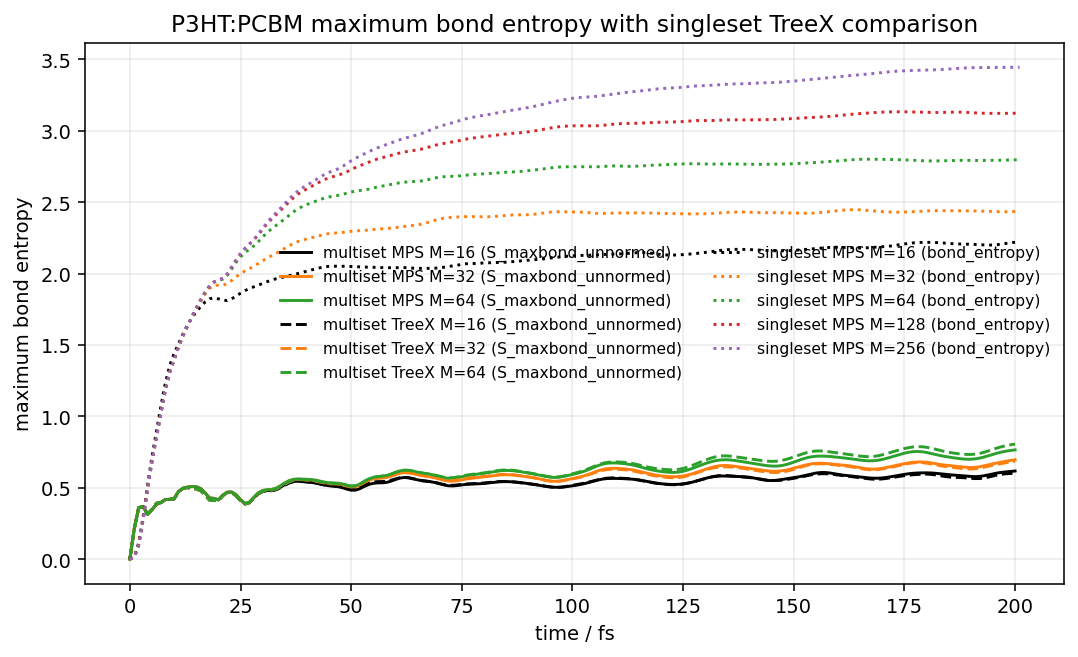

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

AU_TO_FS = globals().get("AU_TO_FS", 0.02418884326505)


def find_repo_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "renormalizer").exists() and (path / "multiset_ttn").exists():
            return path
    return Path.cwd()


repo = globals().get("repo", find_repo_root())
plot_dir = repo / "multiset_ttn/P3HT:PCBM/plot"

multiset_mps_paths = {
    16: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_16.npz",
    32: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_32.npz",
    64: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_64.npz",
    128: repo / "multiset_202605/P3HT:PCBM/multiset/p3ht_multiset_128.npz",
}

multiset_treex_paths = {
    16: repo / "multiset_ttn/P3HT:PCBM/multiset_treeX/p3ht_ms_ttn_treeX_16.npz",
    32: repo / "multiset_ttn/P3HT:PCBM/multiset_treeX/p3ht_ms_ttn_treeX_32.npz",
    64: repo / "multiset_ttn/P3HT:PCBM/multiset_treeX/p3ht_ms_ttn_treeX_64.npz",
}

singleset_mps_paths = {
    16: repo / "multiset_202605/P3HT:PCBM/singleset/p3ht_singleset16.npz",
    32: repo / "multiset_202605/P3HT:PCBM/singleset/p3ht_singleset32.npz",
    64: repo / "multiset_202605/P3HT:PCBM/singleset/p3ht_singleset64.npz",
    128: repo / "multiset_202605/P3HT:PCBM/singleset/p3ht_singleset128.npz",
    256: repo / "multiset_202605/P3HT:PCBM/singleset/p3ht_singleset256.npz",
}

singleset_treex_paths = {
    16: repo / "multiset_ttn/P3HT:PCBM/singleset/p3ht_ttns_16.npz",
    32: repo / "multiset_ttn/P3HT:PCBM/singleset/p3ht_ttns_32.npz",
    64: repo / "multiset_ttn/P3HT:PCBM/singleset/p3ht_ttns_64.npz",
}


def load_time(data, length):
    if "time_fs" in data:
        time = np.real_if_close(data["time_fs"]).squeeze()
    elif "time series" in data:
        time = np.real_if_close(data["time series"]).squeeze() * AU_TO_FS
    else:
        time = np.arange(length)
    if len(time) != length:
        raise ValueError(f"time length {len(time)} != entropy length {length}")
    return time


def max_over_bonds(entropy):
    entropy = np.real_if_close(entropy)
    if getattr(entropy, "dtype", None) == object:
        entropy = np.asarray(entropy, dtype=float)
    entropy = np.asarray(entropy, dtype=float)
    if entropy.ndim == 1:
        return entropy
    return np.nanmax(entropy.reshape(entropy.shape[0], -1), axis=1)


def load_entropy_series(path, preferred_keys):
    with np.load(path, allow_pickle=True) as data:
        for key in preferred_keys:
            if key in data:
                entropy = max_over_bonds(data[key])
                return load_time(data, len(entropy)), entropy, key
        raise KeyError(f"{path.name} has none of {preferred_keys}; keys={list(data.files)}")


multiset_keys = ("S_maxbond_unnormed",)
singleset_keys = (
    "S_maxbond",
    "S_maxbond_normed",
    "S_maxbond_unnormed",
    "bond_entropy",
    "bond_vn_entropy",
    "entropy",
    "S_all",
)

fig, ax = plt.subplots(figsize=(7.8, 4.8), dpi=140)
colors = globals().get("colors", {16: "black", 32: "C1", 64: "C2", 128: "C3", 256: "C4"})
skipped = []
plotted = 0

for max_bd, path in multiset_mps_paths.items():
    try:
        time, entropy, key = load_entropy_series(path, multiset_keys)
    except (FileNotFoundError, KeyError, ValueError) as exc:
        skipped.append(f"multiset MPS M={max_bd}: {exc}")
        continue
    ax.plot(time, entropy, "-", color=colors.get(max_bd), label=f"multiset MPS M={max_bd} ({key})")
    plotted += 1

for max_bd, path in multiset_treex_paths.items():
    try:
        time, entropy, key = load_entropy_series(path, multiset_keys)
    except (FileNotFoundError, KeyError, ValueError) as exc:
        skipped.append(f"multiset TreeX M={max_bd}: {exc}")
        continue
    ax.plot(time, entropy, "--", color=colors.get(max_bd), label=f"multiset TreeX M={max_bd} ({key})")
    plotted += 1

for max_bd, path in singleset_mps_paths.items():
    try:
        time, entropy, key = load_entropy_series(path, singleset_keys)
    except (FileNotFoundError, KeyError, ValueError) as exc:
        skipped.append(f"singleset MPS M={max_bd}: {exc}")
        continue
    ax.plot(time, entropy, ":", color=colors.get(max_bd), label=f"singleset MPS M={max_bd} ({key})")
    plotted += 1

for max_bd, path in singleset_treex_paths.items():
    try:
        time, entropy, key = load_entropy_series(path, singleset_keys)
    except (FileNotFoundError, KeyError, ValueError) as exc:
        skipped.append(f"singleset TreeX M={max_bd}: {exc}")
        continue
    ax.plot(time, entropy, "-.", color=colors.get(max_bd), linewidth=1.8, label=f"singleset TreeX M={max_bd} ({key})")
    plotted += 1

if plotted == 0:
    raise RuntimeError("No usable entropy series were loaded.")

if skipped:
    print("Skipped files without usable maximum bond entropy:")
    for message in skipped:
        print("  " + message)

ax.set_xlabel("time / fs")
ax.set_ylabel("maximum bond entropy")
ax.set_title("P3HT:PCBM maximum bond entropy with singleset TreeX comparison")
ax.grid(alpha=0.25)
ax.legend(frameon=False, ncol=2, fontsize=8)
fig.tight_layout()

out = plot_dir / "p3ht_S_maxbond_unnormed_vs_singleset.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")


saved ../../../multiset_ttn/P3HT:PCBM/plot/p3ht_multiset_treeX_S_el.png


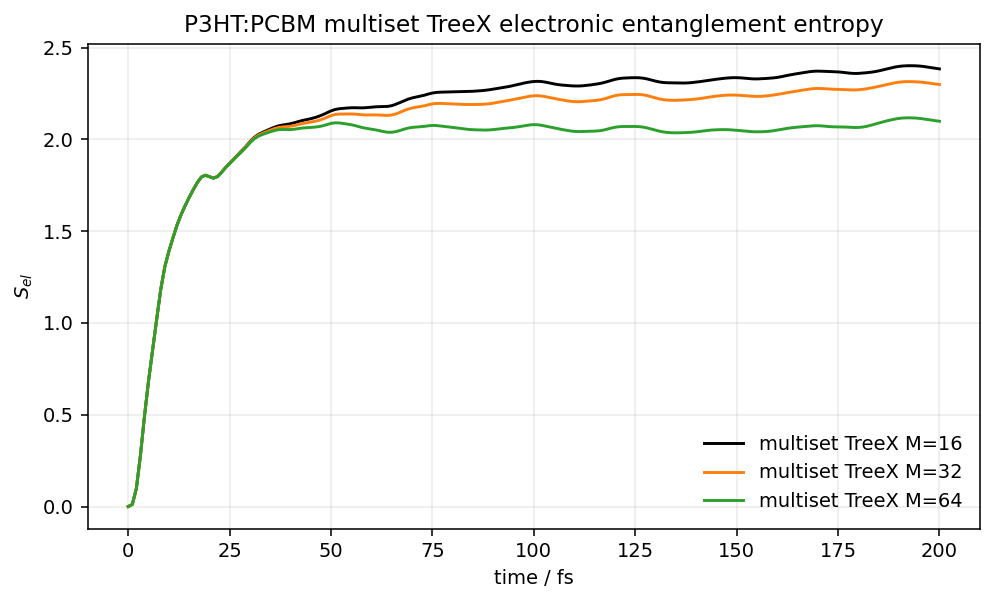

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

AU_TO_FS = globals().get("AU_TO_FS", 0.02418884326505)


def find_repo_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "renormalizer").exists() and (path / "multiset_ttn").exists():
            return path
    return Path.cwd()


repo = globals().get("repo", find_repo_root())
plot_dir = repo / "multiset_ttn/P3HT:PCBM/plot"

treex_paths = {
    16: repo / "multiset_ttn/P3HT:PCBM/multiset_treeX/p3ht_ms_ttn_treeX_16.npz",
    32: repo / "multiset_ttn/P3HT:PCBM/multiset_treeX/p3ht_ms_ttn_treeX_32.npz",
    64: repo / "multiset_ttn/P3HT:PCBM/multiset_treeX/p3ht_ms_ttn_treeX_64.npz",
}


def load_electronic_entropy(path):
    with np.load(path, allow_pickle=True) as data:
        if "S_el" not in data:
            raise KeyError(f"{path.name} has no S_el; keys={list(data.files)}")
        entropy = np.real_if_close(data["S_el"]).squeeze()
        if entropy.ndim != 1:
            raise ValueError(f"{path.name} S_el must be 1D, got {entropy.shape}")
        if "time_fs" in data:
            time = np.real_if_close(data["time_fs"]).squeeze()
        elif "time series" in data:
            time = np.real_if_close(data["time series"]).squeeze() * AU_TO_FS
        else:
            time = np.arange(len(entropy))
        if len(time) != len(entropy):
            raise ValueError(f"{path.name} time length {len(time)} != S_el length {len(entropy)}")
        return time, entropy


fig, ax = plt.subplots(figsize=(7.2, 4.4), dpi=140)
colors = globals().get("colors", {16: "black", 32: "C1", 64: "C2", 128: "C3"})
skipped = []
plotted = 0

for max_bd, path in treex_paths.items():
    try:
        time, entropy = load_electronic_entropy(path)
    except (FileNotFoundError, KeyError, ValueError) as exc:
        skipped.append(f"multiset TreeX M={max_bd}: {exc}")
        continue
    ax.plot(time, entropy, "-", color=colors.get(max_bd), label=f"multiset TreeX M={max_bd}")
    plotted += 1

if plotted == 0:
    raise RuntimeError("No usable S_el series were loaded.")

if skipped:
    print("Skipped files without usable S_el:")
    for message in skipped:
        print("  " + message)

ax.set_xlabel("time / fs")
ax.set_ylabel(r"$S_{el}$")
ax.set_title("P3HT:PCBM multiset TreeX electronic entanglement entropy")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()

out = plot_dir / "p3ht_multiset_treeX_S_el.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")
